# Case Study 2 — Report 7 (Ablation Plots)

**Test 6B (Choice B) + Test 6C (Choice C) full ablation visualizations**

Student: Sanjeev Veeramani (Matr. 100004303)

---

Loads the two summary CSVs from Test 6B-Ablation and Test 6C-Ablation, produces 6 comprehensive plots per choice, plus a side-by-side comparison.

Prerequisites (already generated by the ablation notebooks):
- `results/report7_test6B_ablation/summary_test6B_ablation.csv`
- `results/report7_test6C_ablation/summary_test6C_ablation.csv`

Outputs saved to: `results/report7_plots/`

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from pathlib import Path

plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

ROOT = Path(PROJECT_ROOT)
PLOTS_DIR = ROOT / 'results' / 'report7_plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Plots will be saved to: {PLOTS_DIR}')

Plots will be saved to: /content/drive/MyDrive/case_study_2/results/report7_plots


## 2. Load summary CSVs

In [3]:
T6B = pd.read_csv(ROOT / 'results/report7_test6B_ablation/summary_test6B_ablation.csv')
T6C = pd.read_csv(ROOT / 'results/report7_test6C_ablation/summary_test6C_ablation.csv')

print('Test 6B (Choice B):', T6B.shape, 'rows')
print('Test 6C (Choice C):', T6C.shape, 'rows')

# Reference numbers
IMTIAZ_KHAN = 67.44   # DEAP → SEED binary, their reported number
IMTIAZ_BASELINE_A = 54.24   # pre-training only, no DA
IMTIAZ_BASELINE_B = 60.35   # baseline UDA without their techniques

# Order for plotting
COMBOS_ORDER = [f'E{e}A{a}F{f}T{t}' for e,a,f,t in itertools.product([0,1], repeat=4)]
print('16 combos order:', COMBOS_ORDER)

Test 6B (Choice B): (64, 13) rows
Test 6C (Choice C): (64, 13) rows
16 combos order: ['E0A0F0T0', 'E0A0F0T1', 'E0A0F1T0', 'E0A0F1T1', 'E0A1F0T0', 'E0A1F0T1', 'E0A1F1T0', 'E0A1F1T1', 'E1A0F0T0', 'E1A0F0T1', 'E1A0F1T0', 'E1A0F1T1', 'E1A1F0T0', 'E1A1F0T1', 'E1A1F1T0', 'E1A1F1T1']


## 3. Plot helpers

In [4]:
def get_config(df, mapping, protocol):
    return df[(df['mapping'] == mapping) & (df['protocol'] == protocol)].copy()

def chance_for(mapping):
    return 50.0 if mapping == 'binary' else (100.0 / 3.0)

CONFIGS = [(m, p) for m in ['binary', '3class'] for p in ['per_trial', 'per_window']]
CHOICE_COLOR = {'B': '#4472C4', 'C': '#ED7D31'}

## Plot 1 — Full 16-combination heatmap per config (both choices)

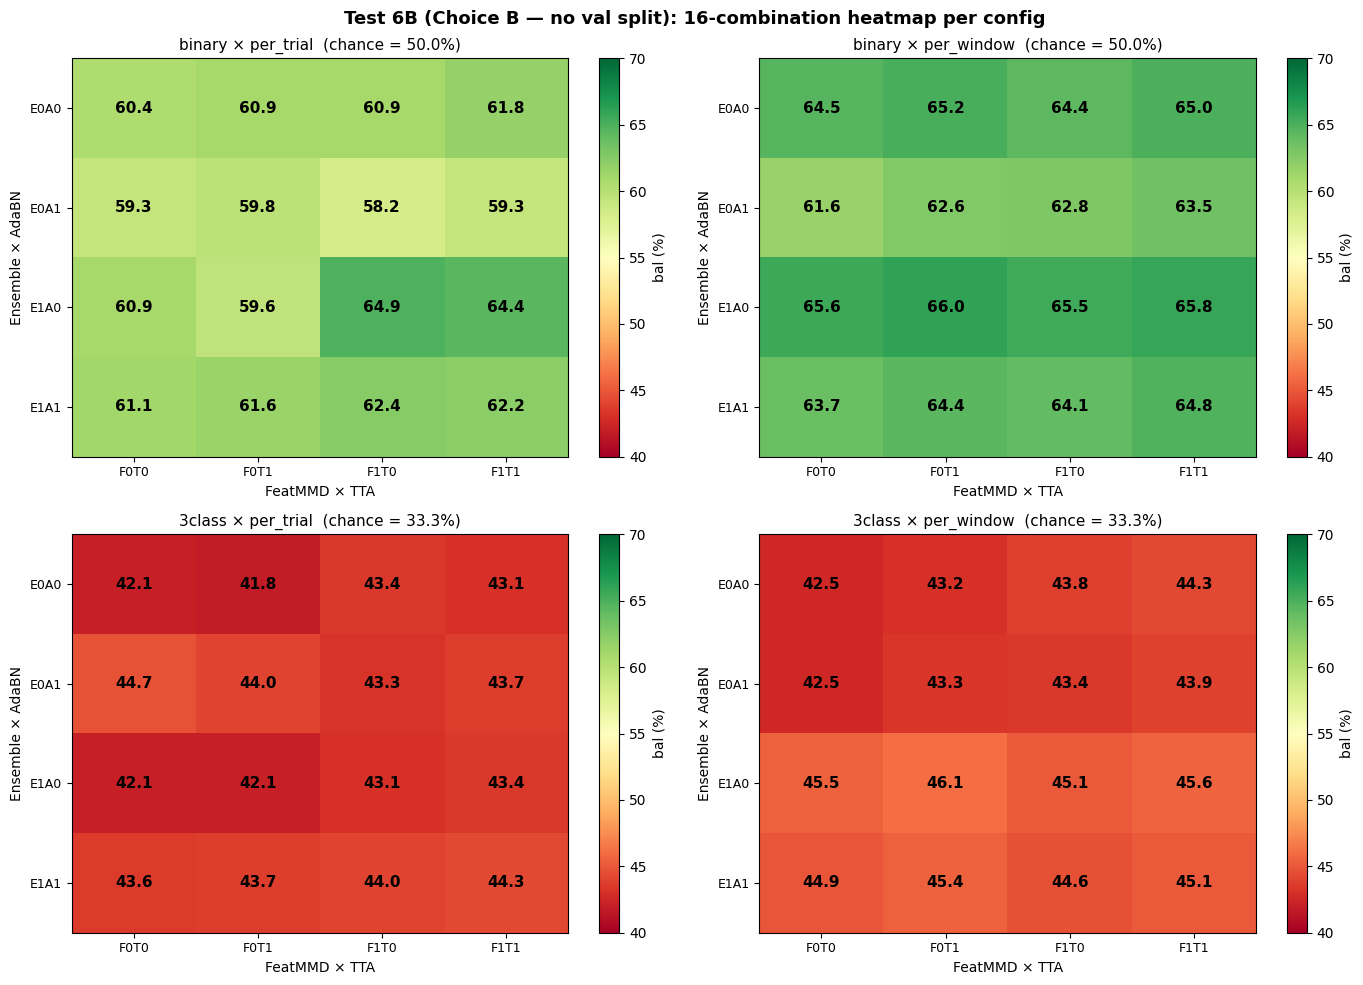

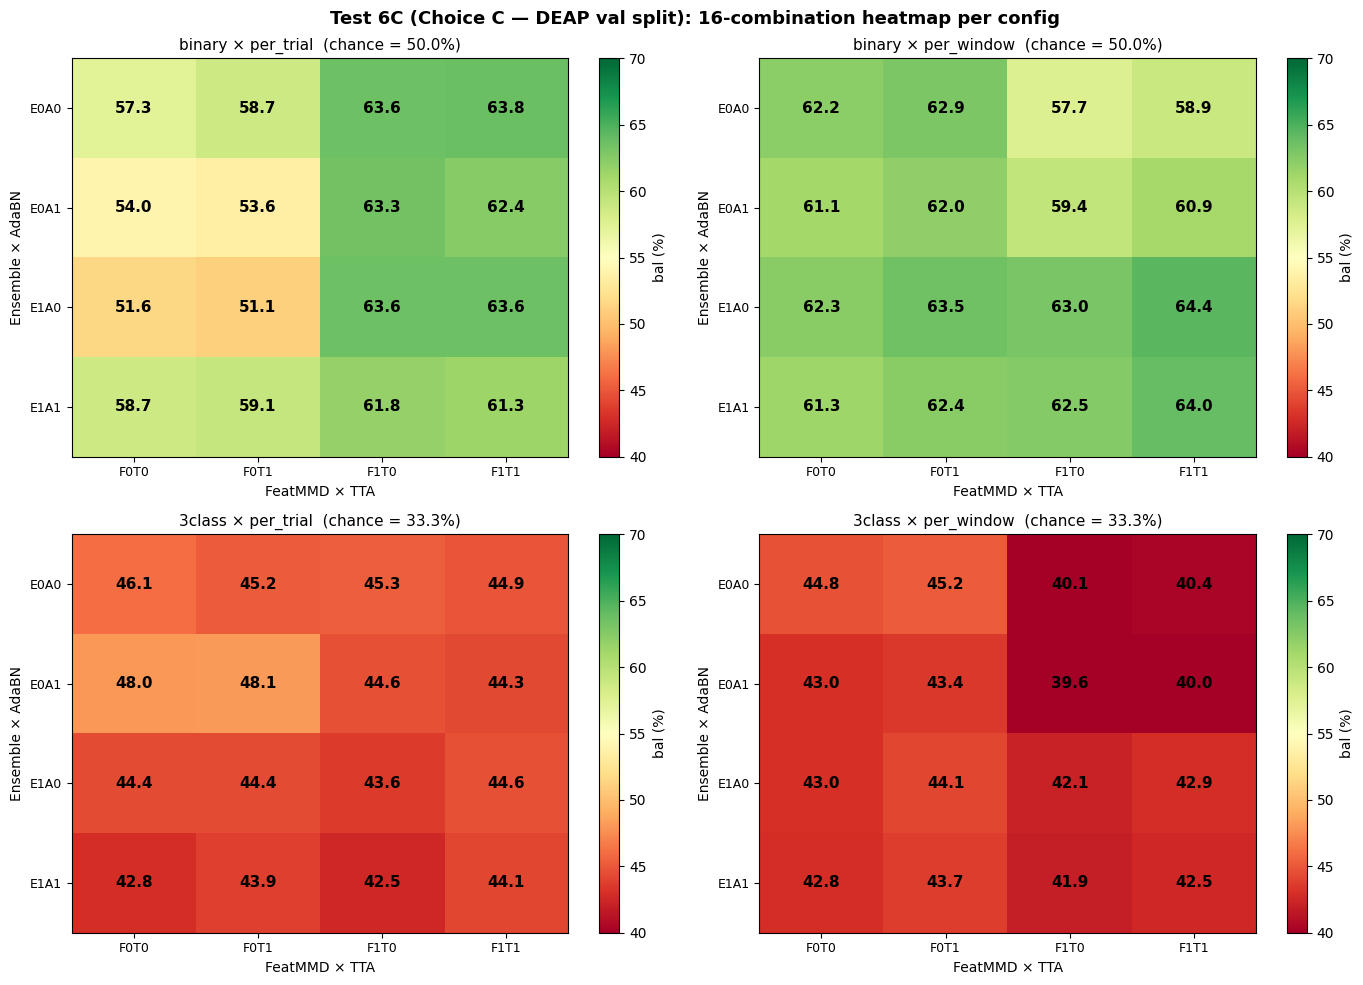

In [5]:
def plot_heatmap(df, choice_name, filename):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (mapping, protocol) in zip(axes.flatten(), CONFIGS):
        sub = get_config(df, mapping, protocol).set_index('combo').loc[COMBOS_ORDER]
        vals = sub['bal'].values.reshape(4, 4)   # 4 F/T combos × 4 E/A combos
        # Rows: (E, A) ; Cols: (F, T)
        row_labels = [f'E{e}A{a}' for e, a in itertools.product([0,1], repeat=2)]
        col_labels = [f'F{f}T{t}' for f, t in itertools.product([0,1], repeat=2)]
        grid = np.zeros((4, 4))
        for i, (E, A) in enumerate(itertools.product([0,1], repeat=2)):
            for j, (F, T) in enumerate(itertools.product([0,1], repeat=2)):
                combo = f'E{E}A{A}F{F}T{T}'
                grid[i, j] = sub.loc[combo, 'bal']
        im = ax.imshow(grid, cmap='RdYlGn', aspect='auto',
                       vmin=40, vmax=max(70, grid.max() + 2))
        for i in range(4):
            for j in range(4):
                ax.text(j, i, f'{grid[i,j]:.1f}', ha='center', va='center',
                        fontsize=11, fontweight='bold')
        ax.set_xticks(range(4)); ax.set_xticklabels(col_labels, fontsize=9)
        ax.set_yticks(range(4)); ax.set_yticklabels(row_labels, fontsize=9)
        ch = chance_for(mapping)
        ax.set_title(f'{mapping} × {protocol}  (chance = {ch:.1f}%)', fontsize=11)
        ax.set_xlabel('FeatMMD × TTA'); ax.set_ylabel('Ensemble × AdaBN')
        plt.colorbar(im, ax=ax, label='bal (%)')
    plt.suptitle(f'{choice_name}: 16-combination heatmap per config',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=140, bbox_inches='tight')
    plt.show()

plot_heatmap(T6B, 'Test 6B (Choice B — no val split)', 'plot1_heatmap_choiceB.png')
plot_heatmap(T6C, 'Test 6C (Choice C — DEAP val split)', 'plot1_heatmap_choiceC.png')

## Plot 2 — Top 8 combinations per config (ranked)

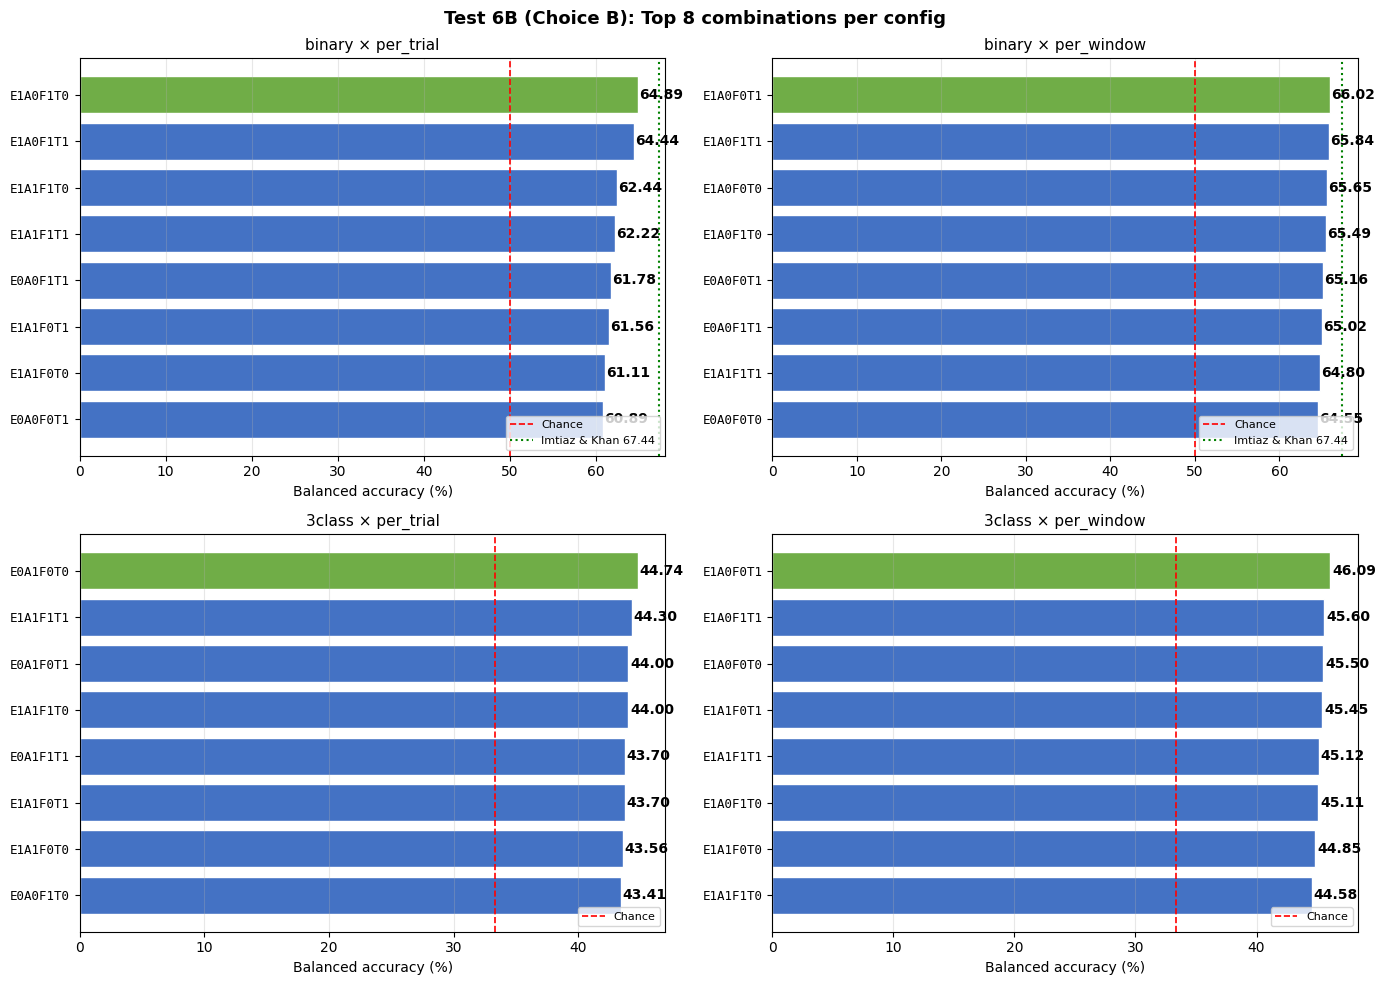

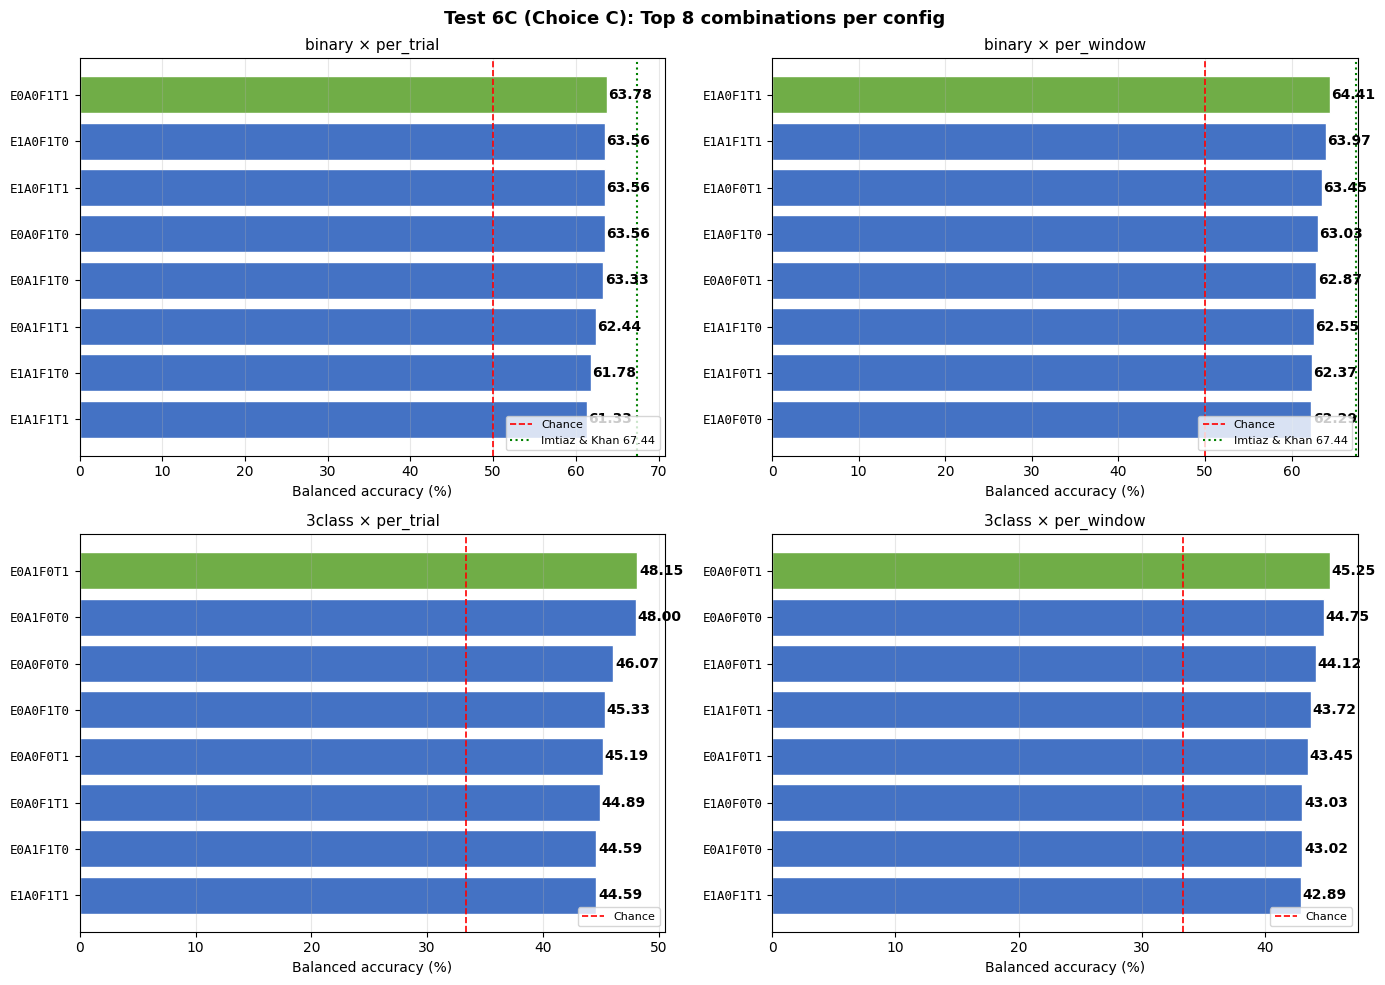

In [6]:
def plot_top8(df, choice_name, filename):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (mapping, protocol) in zip(axes.flatten(), CONFIGS):
        sub = get_config(df, mapping, protocol).nlargest(8, 'bal')
        y = np.arange(len(sub))[::-1]
        colors = ['#70AD47' if i == 0 else '#4472C4' for i in range(len(sub))]
        bars = ax.barh(y, sub['bal'].values, color=colors, edgecolor='white')
        for b, v in zip(bars, sub['bal'].values):
            ax.text(v + 0.15, b.get_y() + b.get_height()/2, f'{v:.2f}',
                    va='center', fontsize=10, fontweight='bold')
        ax.set_yticks(y); ax.set_yticklabels(sub['combo'].values, fontsize=9,
                                              family='monospace')
        ch = chance_for(mapping)
        ax.axvline(ch, color='red', linestyle='--', linewidth=1.2, label='Chance')
        if mapping == 'binary':
            ax.axvline(IMTIAZ_KHAN, color='green', linestyle=':', linewidth=1.5,
                       label=f'Imtiaz & Khan {IMTIAZ_KHAN}')
        ax.set_xlabel('Balanced accuracy (%)')
        ax.set_title(f'{mapping} × {protocol}', fontsize=11)
        ax.legend(loc='lower right', fontsize=8); ax.grid(axis='x', alpha=0.3)
    plt.suptitle(f'{choice_name}: Top 8 combinations per config',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=140, bbox_inches='tight')
    plt.show()

plot_top8(T6B, 'Test 6B (Choice B)', 'plot2_top8_choiceB.png')
plot_top8(T6C, 'Test 6C (Choice C)', 'plot2_top8_choiceC.png')

## Plot 3 — Isolated technique contributions vs baseline

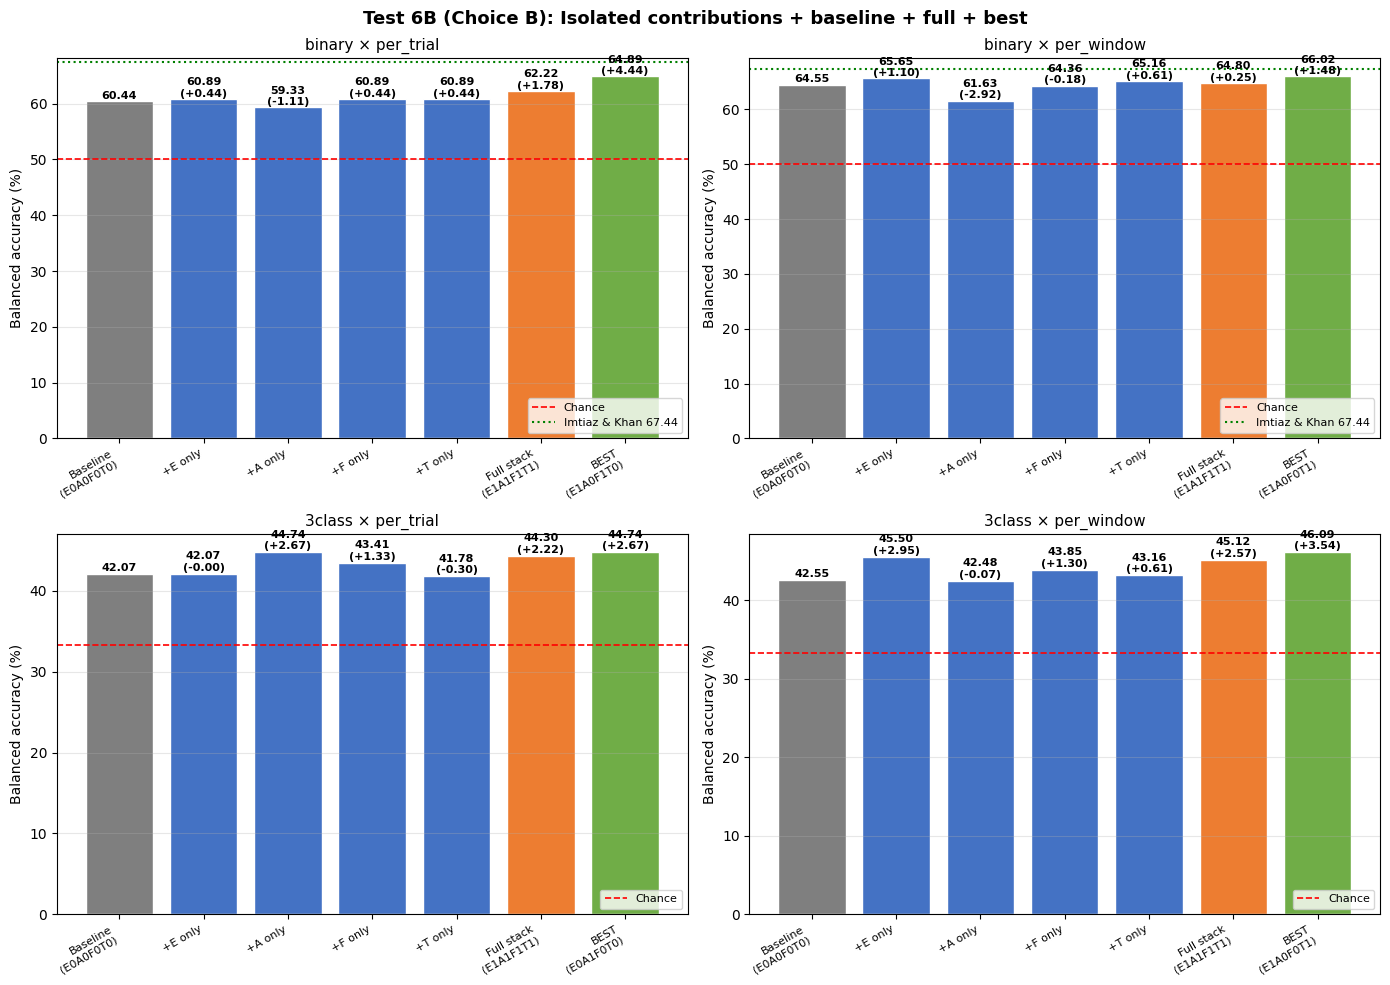

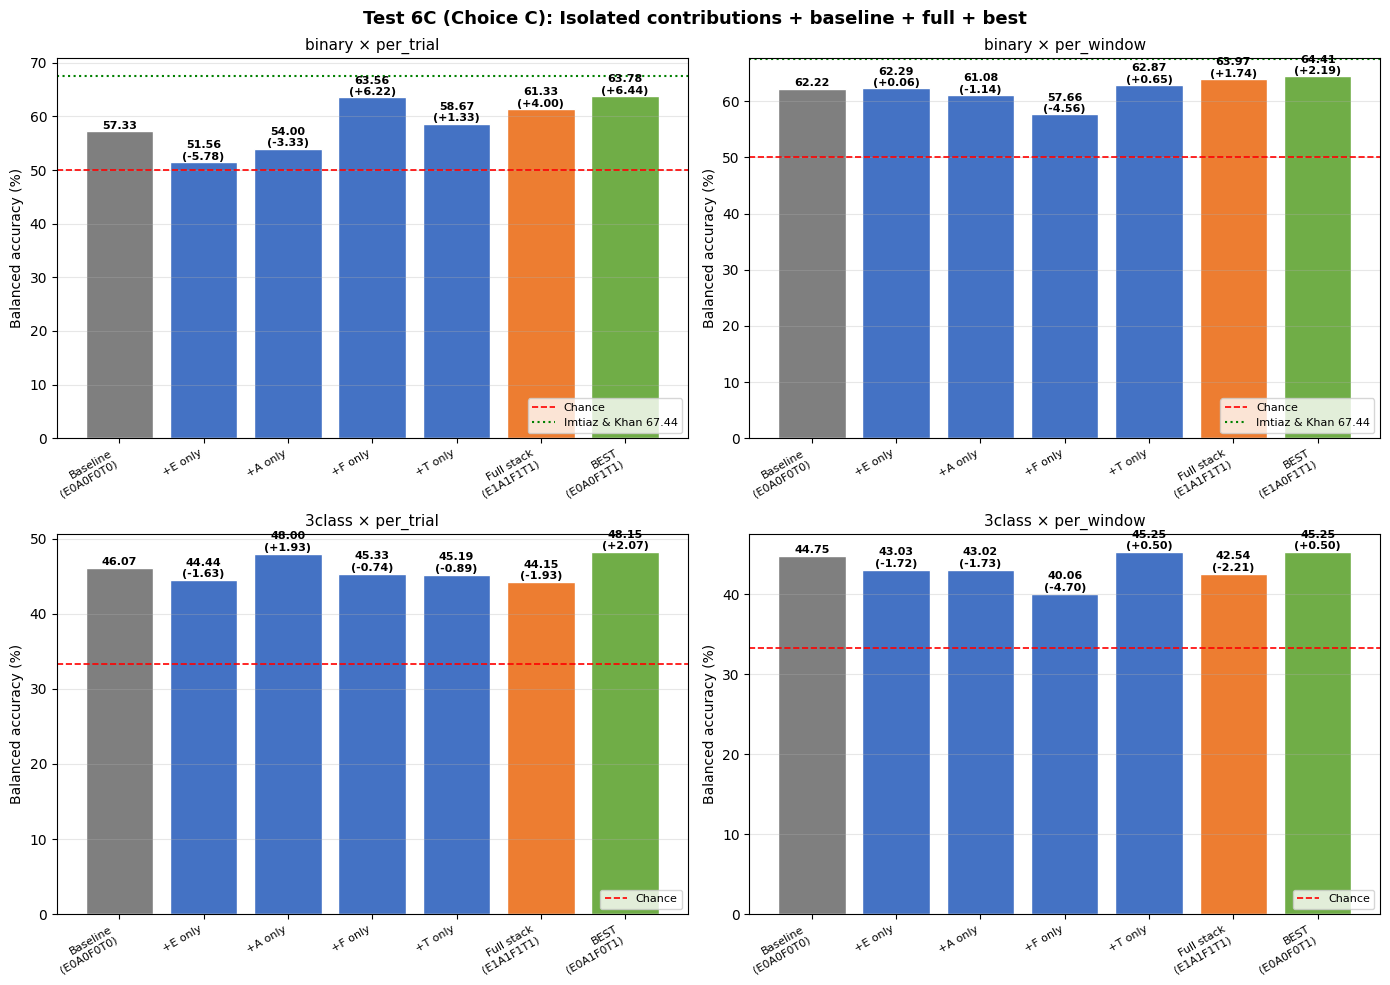

In [7]:
def plot_isolated(df, choice_name, filename):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (mapping, protocol) in zip(axes.flatten(), CONFIGS):
        sub = get_config(df, mapping, protocol)
        baseline = sub[sub['combo'] == 'E0A0F0T0']['bal'].values[0]
        e_only = sub[sub['combo'] == 'E1A0F0T0']['bal'].values[0]
        a_only = sub[sub['combo'] == 'E0A1F0T0']['bal'].values[0]
        f_only = sub[sub['combo'] == 'E0A0F1T0']['bal'].values[0]
        t_only = sub[sub['combo'] == 'E0A0F0T1']['bal'].values[0]
        full   = sub[sub['combo'] == 'E1A1F1T1']['bal'].values[0]
        best   = sub['bal'].max()
        best_combo = sub.loc[sub['bal'].idxmax(), 'combo']

        labels = ['Baseline\n(E0A0F0T0)', '+E only', '+A only', '+F only',
                  '+T only', 'Full stack\n(E1A1F1T1)', f'BEST\n({best_combo})']
        vals   = [baseline, e_only, a_only, f_only, t_only, full, best]
        deltas = [0] + [v - baseline for v in vals[1:]]
        colors = ['#7f7f7f', '#4472C4', '#4472C4', '#4472C4', '#4472C4',
                  '#ED7D31', '#70AD47']
        x = np.arange(len(labels))
        bars = ax.bar(x, vals, color=colors, edgecolor='white')
        for i, (b, v, d) in enumerate(zip(bars, vals, deltas)):
            dlbl = f'{v:.2f}' + (f'\n({d:+.2f})' if d != 0 else '')
            ax.text(b.get_x() + b.get_width()/2, v + 0.4, dlbl,
                    ha='center', fontsize=8, fontweight='bold')

        ch = chance_for(mapping)
        ax.axhline(ch, color='red', linestyle='--', linewidth=1.2, label='Chance')
        if mapping == 'binary':
            ax.axhline(IMTIAZ_KHAN, color='green', linestyle=':', linewidth=1.5,
                       label=f'Imtiaz & Khan {IMTIAZ_KHAN}')
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, fontsize=8, ha='right')
        ax.set_ylabel('Balanced accuracy (%)')
        ax.set_title(f'{mapping} × {protocol}', fontsize=11)
        ax.legend(loc='lower right', fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.suptitle(f'{choice_name}: Isolated contributions + baseline + full + best',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=140, bbox_inches='tight')
    plt.show()

plot_isolated(T6B, 'Test 6B (Choice B)', 'plot3_isolated_choiceB.png')
plot_isolated(T6C, 'Test 6C (Choice C)', 'plot3_isolated_choiceC.png')

## Plot 4 — Best-so-far by number of active techniques

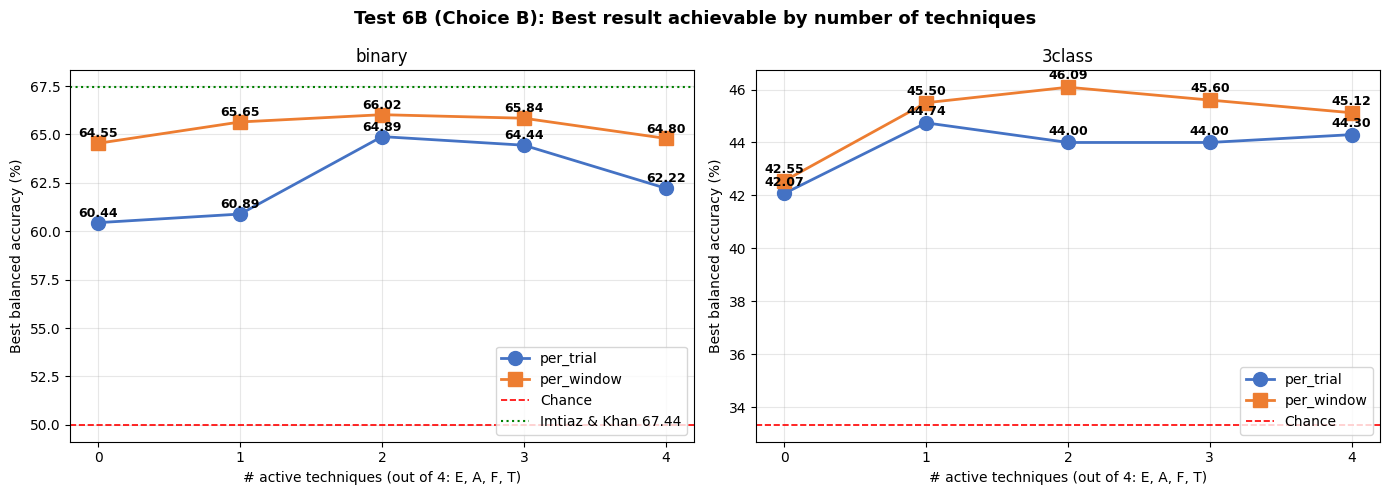

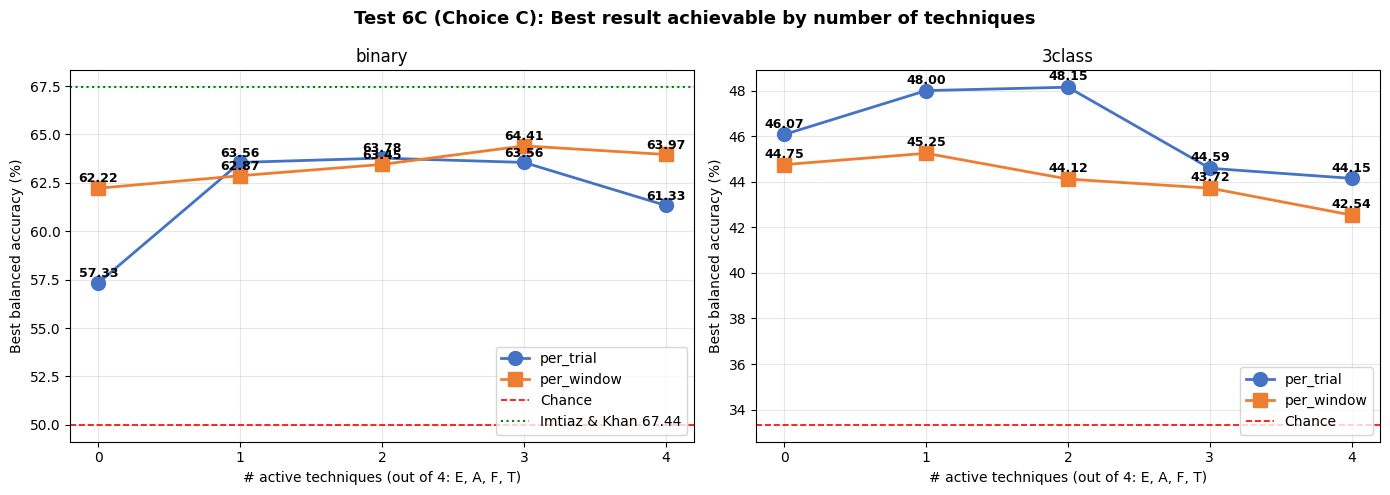

In [8]:
def plot_progressive(df, choice_name, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mapping in zip(axes, ['binary', '3class']):
        for protocol, marker, color in [('per_trial', 'o', '#4472C4'),
                                         ('per_window', 's', '#ED7D31')]:
            sub = get_config(df, mapping, protocol).copy()
            sub['n_active'] = sub['E'] + sub['A'] + sub['F'] + sub['T']
            best_by_n = sub.groupby('n_active')['bal'].max().reset_index()
            ax.plot(best_by_n['n_active'], best_by_n['bal'], marker=marker,
                    color=color, linewidth=2, markersize=10, label=protocol)
            for _, r in best_by_n.iterrows():
                ax.text(r['n_active'], r['bal'] + 0.3, f'{r["bal"]:.2f}',
                        ha='center', fontsize=9, fontweight='bold')
        ch = chance_for(mapping)
        ax.axhline(ch, color='red', linestyle='--', linewidth=1.2, label='Chance')
        if mapping == 'binary':
            ax.axhline(IMTIAZ_KHAN, color='green', linestyle=':', linewidth=1.5,
                       label=f'Imtiaz & Khan {IMTIAZ_KHAN}')
        ax.set_xlabel('# active techniques (out of 4: E, A, F, T)')
        ax.set_ylabel('Best balanced accuracy (%)')
        ax.set_title(f'{mapping}')
        ax.legend(loc='lower right'); ax.grid(alpha=0.3)
        ax.set_xticks([0, 1, 2, 3, 4])
    plt.suptitle(f'{choice_name}: Best result achievable by number of techniques',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=140, bbox_inches='tight')
    plt.show()

plot_progressive(T6B, 'Test 6B (Choice B)', 'plot4_progressive_choiceB.png')
plot_progressive(T6C, 'Test 6C (Choice C)', 'plot4_progressive_choiceC.png')

## Plot 5 — Marginal effect of each technique (averaged across all other combos)

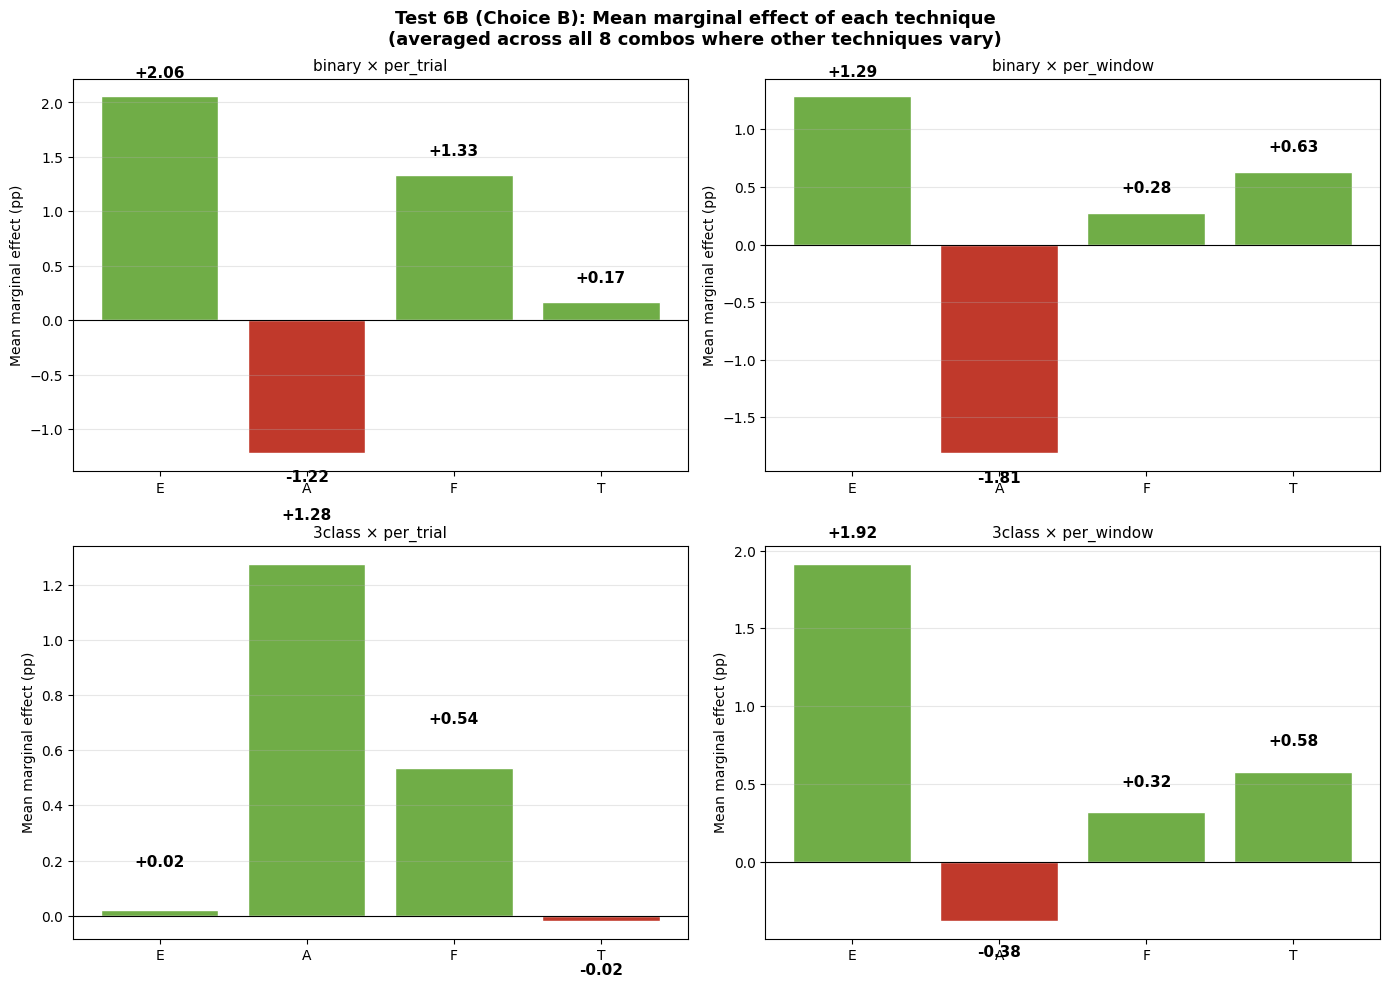

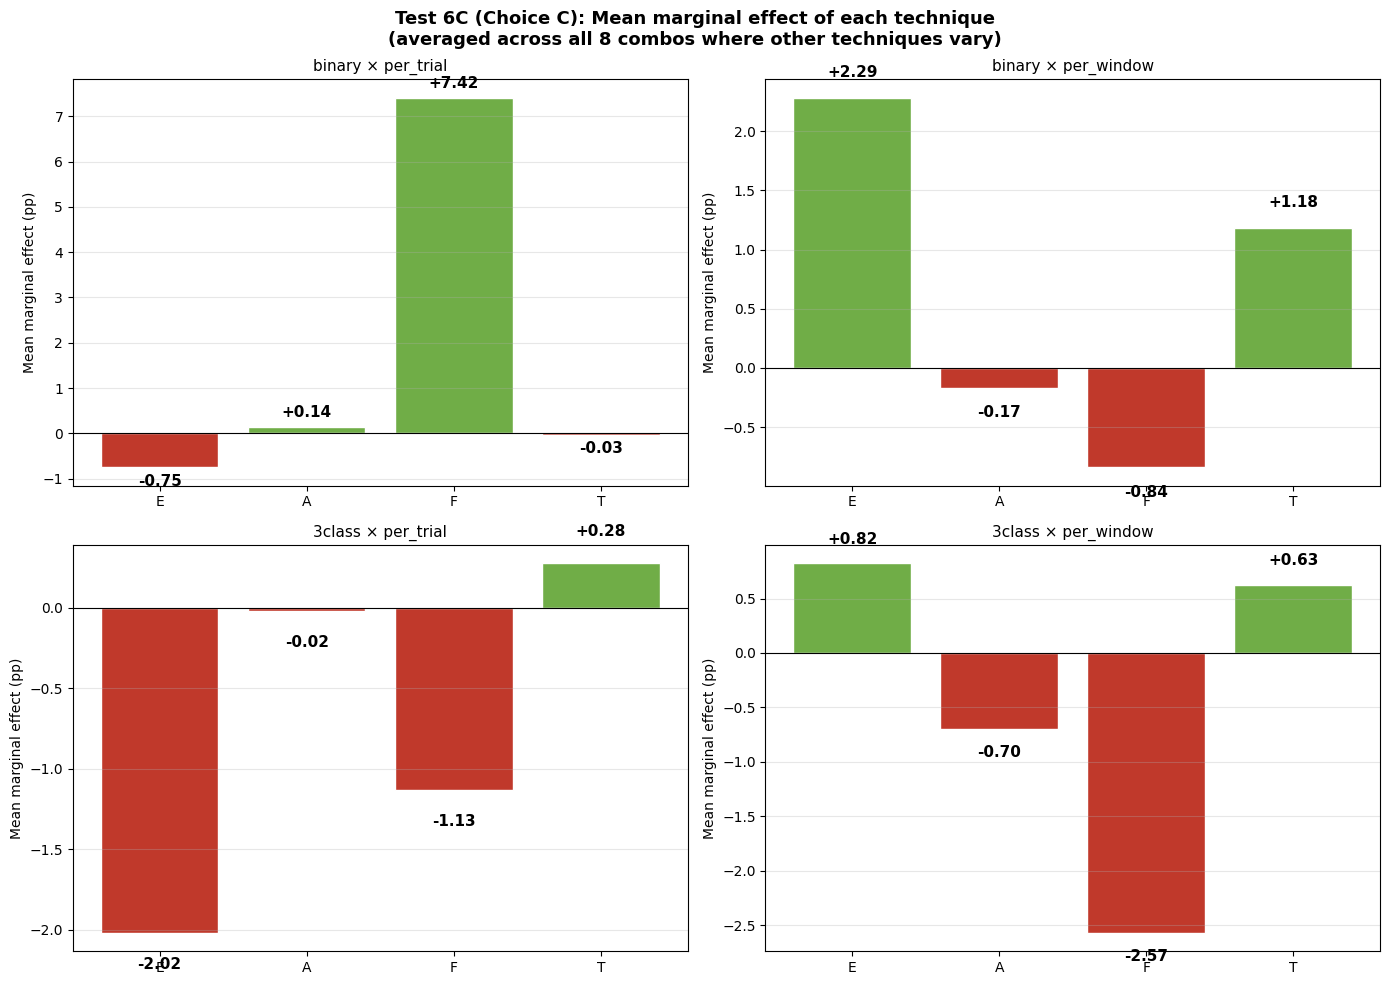

In [9]:
def plot_marginal(df, choice_name, filename):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (mapping, protocol) in zip(axes.flatten(), CONFIGS):
        sub = get_config(df, mapping, protocol)
        # For each technique, compute mean(bal | tech=1) - mean(bal | tech=0)
        marginals = {}
        for tech in ['E', 'A', 'F', 'T']:
            with_t    = sub[sub[tech] == 1]['bal'].mean()
            without_t = sub[sub[tech] == 0]['bal'].mean()
            marginals[tech] = with_t - without_t

        techs = list(marginals.keys())
        vals  = list(marginals.values())
        colors = ['#70AD47' if v > 0 else '#c0392b' for v in vals]
        bars = ax.bar(techs, vals, color=colors, edgecolor='white')
        for b, v in zip(bars, vals):
            va = 'bottom' if v > 0 else 'top'
            offset = 0.15 if v > 0 else -0.15
            ax.text(b.get_x() + b.get_width()/2, v + offset,
                    f'{v:+.2f}', ha='center', va=va, fontsize=11, fontweight='bold')

        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel('Mean marginal effect (pp)')
        ax.set_title(f'{mapping} × {protocol}', fontsize=11)
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle(f'{choice_name}: Mean marginal effect of each technique\n'
                 f'(averaged across all 8 combos where other techniques vary)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=140, bbox_inches='tight')
    plt.show()

plot_marginal(T6B, 'Test 6B (Choice B)', 'plot5_marginal_choiceB.png')
plot_marginal(T6C, 'Test 6C (Choice C)', 'plot5_marginal_choiceC.png')

## Plot 6 — Choice B vs Choice C: side-by-side comparison

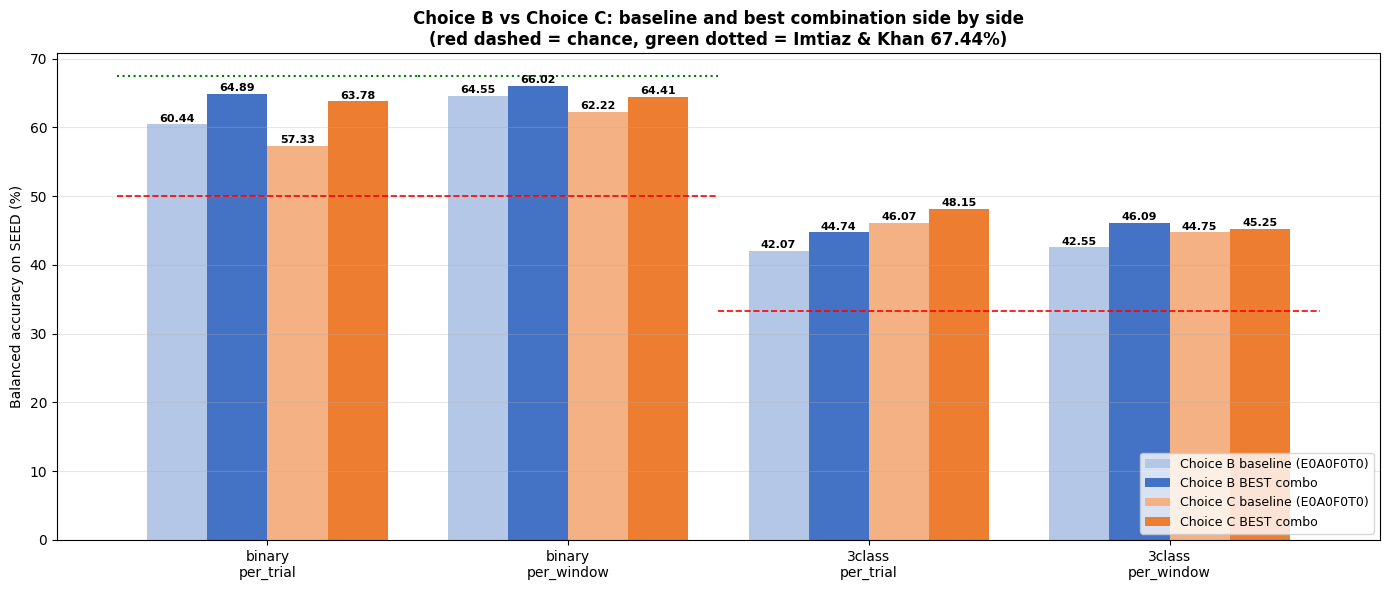

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

configs_labels = [f'{m}\n{p}' for m, p in CONFIGS]
baselines_B, best_B = [], []
baselines_C, best_C = [], []

for (mapping, protocol) in CONFIGS:
    sB = get_config(T6B, mapping, protocol)
    sC = get_config(T6C, mapping, protocol)
    baselines_B.append(sB[sB['combo'] == 'E0A0F0T0']['bal'].values[0])
    best_B.append(sB['bal'].max())
    baselines_C.append(sC[sC['combo'] == 'E0A0F0T0']['bal'].values[0])
    best_C.append(sC['bal'].max())

x = np.arange(len(configs_labels)); w = 0.2
b1 = ax.bar(x - 1.5*w, baselines_B, w, label='Choice B baseline (E0A0F0T0)', color='#B4C7E7')
b2 = ax.bar(x - 0.5*w, best_B,      w, label='Choice B BEST combo',          color='#4472C4')
b3 = ax.bar(x + 0.5*w, baselines_C, w, label='Choice C baseline (E0A0F0T0)', color='#F4B183')
b4 = ax.bar(x + 1.5*w, best_C,      w, label='Choice C BEST combo',          color='#ED7D31')

for bars, vals in [(b1, baselines_B), (b2, best_B), (b3, baselines_C), (b4, best_C)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.4, f'{v:.2f}',
                ha='center', fontsize=8, fontweight='bold')

# Chance and Imtiaz & Khan lines
for i, (m, p) in enumerate(CONFIGS):
    ch = chance_for(m)
    ax.hlines(ch, x[i] - 0.5, x[i] + 0.5, colors='red', linestyles='dashed', linewidth=1.2)
    if m == 'binary':
        ax.hlines(IMTIAZ_KHAN, x[i] - 0.5, x[i] + 0.5,
                  colors='green', linestyles=':', linewidth=1.5)

ax.set_xticks(x); ax.set_xticklabels(configs_labels)
ax.set_ylabel('Balanced accuracy on SEED (%)')
ax.set_title('Choice B vs Choice C: baseline and best combination side by side\n'
             '(red dashed = chance, green dotted = Imtiaz & Khan 67.44%)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot6_choiceB_vs_choiceC.png', dpi=140, bbox_inches='tight')
plt.show()

## Plot 7 — Final scoreboard vs Imtiaz & Khan (binary only)

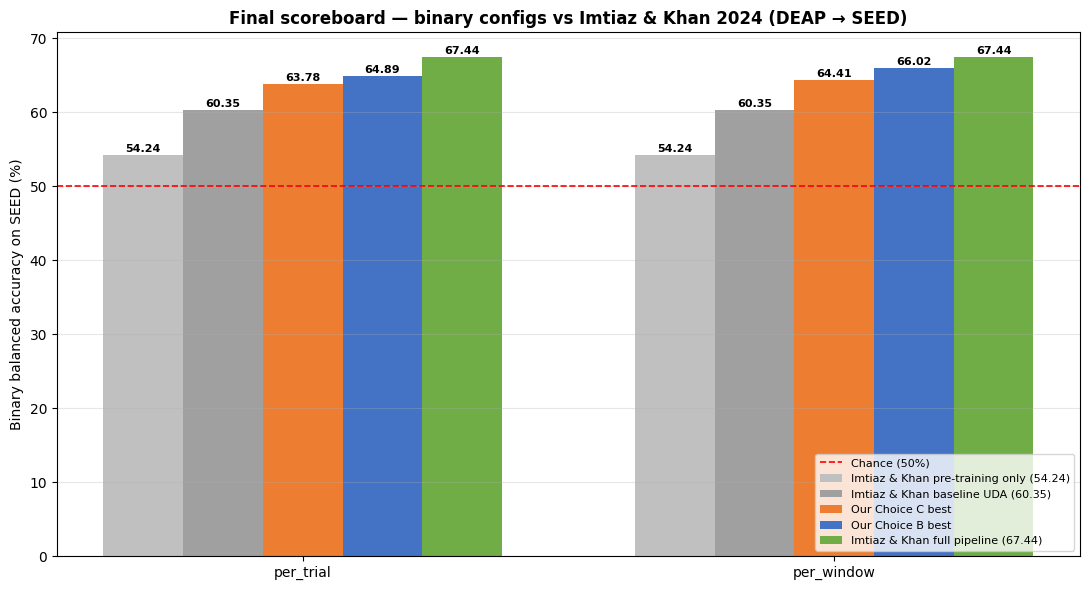

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

configs_bin = [(m, p) for m, p in CONFIGS if m == 'binary']
labels = [p for m, p in configs_bin]

# 5 bars per config: Imtiaz baseline A, Imtiaz baseline B, Choice B best, Choice C best, Imtiaz full
their_A = [IMTIAZ_BASELINE_A] * len(labels)
their_B = [IMTIAZ_BASELINE_B] * len(labels)
their_full = [IMTIAZ_KHAN] * len(labels)
our_B = [get_config(T6B, 'binary', p)['bal'].max() for p in labels]
our_C = [get_config(T6C, 'binary', p)['bal'].max() for p in labels]

x = np.arange(len(labels)); w = 0.15
bars_a = ax.bar(x - 2*w, their_A,   w, label=f'Imtiaz & Khan pre-training only ({IMTIAZ_BASELINE_A})',   color='#c0c0c0')
bars_b = ax.bar(x - w,   their_B,   w, label=f'Imtiaz & Khan baseline UDA ({IMTIAZ_BASELINE_B})',        color='#a0a0a0')
bars_C = ax.bar(x,       our_C,     w, label='Our Choice C best', color='#ED7D31')
bars_B = ax.bar(x + w,   our_B,     w, label='Our Choice B best', color='#4472C4')
bars_f = ax.bar(x + 2*w, their_full, w, label=f'Imtiaz & Khan full pipeline ({IMTIAZ_KHAN})',            color='#70AD47')

for bars, vals in [(bars_a, their_A), (bars_b, their_B), (bars_C, our_C),
                    (bars_B, our_B), (bars_f, their_full)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.4, f'{v:.2f}',
                ha='center', fontsize=8, fontweight='bold')

ax.axhline(50.0, color='red', linestyle='--', linewidth=1.2, label='Chance (50%)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Binary balanced accuracy on SEED (%)')
ax.set_title('Final scoreboard — binary configs vs Imtiaz & Khan 2024 (DEAP → SEED)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot7_final_scoreboard.png', dpi=140, bbox_inches='tight')
plt.show()

## Plot 8 — Summary table (for the R7 docx)

In [12]:
# Build a final summary table
rows = []
for (mapping, protocol) in CONFIGS:
    for name, df in [('Choice B', T6B), ('Choice C', T6C)]:
        sub = get_config(df, mapping, protocol)
        baseline = sub[sub['combo'] == 'E0A0F0T0']['bal'].values[0]
        best = sub['bal'].max()
        best_combo = sub.loc[sub['bal'].idxmax(), 'combo']
        rows.append({
            'choice': name,
            'mapping': mapping,
            'protocol': protocol,
            'baseline': round(baseline, 2),
            'best_combo': best_combo,
            'best_bal': round(best, 2),
            'gain_over_baseline': round(best - baseline, 2),
            'vs_ImtiazKhan': round(best - IMTIAZ_KHAN, 2) if mapping == 'binary' else None,
            'beats_67.44?': (best > IMTIAZ_KHAN) if mapping == 'binary' else None,
        })
FINAL = pd.DataFrame(rows)
FINAL.to_csv(PLOTS_DIR / 'final_summary.csv', index=False)
print(FINAL.to_string(index=False))

  choice mapping   protocol  baseline best_combo  best_bal  gain_over_baseline  vs_ImtiazKhan beats_67.44?
Choice B  binary  per_trial     60.44   E1A0F1T0     64.89                4.44          -2.55        False
Choice C  binary  per_trial     57.33   E0A0F1T1     63.78                6.44          -3.66        False
Choice B  binary per_window     64.55   E1A0F0T1     66.02                1.48          -1.42        False
Choice C  binary per_window     62.22   E1A0F1T1     64.41                2.19          -3.03        False
Choice B  3class  per_trial     42.07   E0A1F0T0     44.74                2.67            NaN         None
Choice C  3class  per_trial     46.07   E0A1F0T1     48.15                2.07            NaN         None
Choice B  3class per_window     42.55   E1A0F0T1     46.09                3.54            NaN         None
Choice C  3class per_window     44.75   E0A0F0T1     45.25                0.50            NaN         None


## Done

All plots and the summary CSV saved to `/results/report7_plots/`:

- `plot1_heatmap_choiceB.png`, `plot1_heatmap_choiceC.png`
- `plot2_top8_choiceB.png`, `plot2_top8_choiceC.png`
- `plot3_isolated_choiceB.png`, `plot3_isolated_choiceC.png`
- `plot4_progressive_choiceB.png`, `plot4_progressive_choiceC.png`
- `plot5_marginal_choiceB.png`, `plot5_marginal_choiceC.png`
- `plot6_choiceB_vs_choiceC.png`
- `plot7_final_scoreboard.png`
- `final_summary.csv`

Use these directly in the R7 docx.